# Breast cancer forward selection with a mixed kernel

This compact example adapts the existing breast-cancer forward-selection workflow to a weighted sum of linear and RBF kernels. Selection candidates are `(kernel, feature)` pairs, so removing a measurement from one kernel does not remove it from the other.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from mistic import (
    MixedKernel, combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet,
)

## Development and blind holdout data

The scaler is fitted only on the development partition, keeping the holdout blind until the final evaluation.

In [13]:
# Import dataset
dataTable = pd.read_csv("wdbc.data", sep = ",",header=None) 
properties = ["Radius","Texture","Perimeter","Area","Smoothness","Compactness","Concavity","Concave Points","Symmetry","Fractal Dimension"]
names = ["ID", "Diagnosis"]+[p+" mean" for p in properties]+[p+" SE" for p in properties]+[p+" worst" for p in properties]
dataTable.columns = pd.Index(names)
dataTable

X = dataTable.copy()
X.drop(columns=['ID','Diagnosis'],inplace=True)
y_all = dataTable.iloc[:,1]

X_train, X_test, y_train, y_test = train_test_split(X, y_all, 
                                                    stratify = y_all, 
                                                    random_state= 0, 
                                                    test_size= 1/5)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

cv_set = cvSet(X = X_train, y = y_train.values)
cv_set.classification(num_sets = 5)

## Define and tune the mixed kernel

The weight names become ordinary kernel hyperparameters. The grid below compares three linear/RBF balances and three RBF length scales. Nonnegative weights preserve positive semidefiniteness.

In [14]:
candidate_features = np.arange(0, 30)  # keep the pair search quick

mixed_kernel = MixedKernel.weighted_sum(
    [
        kernelWrapper("linear", name="linear", features=candidate_features),
        kernelWrapper("rbf", name="radial", features=candidate_features),
    ],
    weight_parameters=["linear_weight", "rbf_weight"],
)

parameter_grid = [
    paramSet(
        model={"C": C},
        kernel={
            "radial__gamma": gamma,
            "linear_weight": linear_weight,
            "rbf_weight": 1.0 - linear_weight,
        },
    )

    for C in (0.5, 2.0)
    for gamma in (2**-7, 2**-3)
    for linear_weight in (0.25, 0.75)
]

model = svmSet(
    SVC(kernel="precomputed", class_weight="balanced"),
    cv_set,
    score_method=score_svc().score,
    kernel= mixed_kernel,
    feature_set_policy="shared",
    kernel_feature_selection="independent",
)

## Greedy forward selection

For a quick demonstration, both kernels may use the first six measurements and the search is capped at three kernel-feature pairs. The same original feature may be selected for one or both kernels.

In [ ]:
model.greedy_forward_kernel_selection(
    parameter_grid=parameter_grid,
    max_kernel_features=15,
)

performance = pd.DataFrame(model.feature_performance_).T
performance[["num_kernel_features", "num_features", "added_kernel", "added_feature", "score"]]

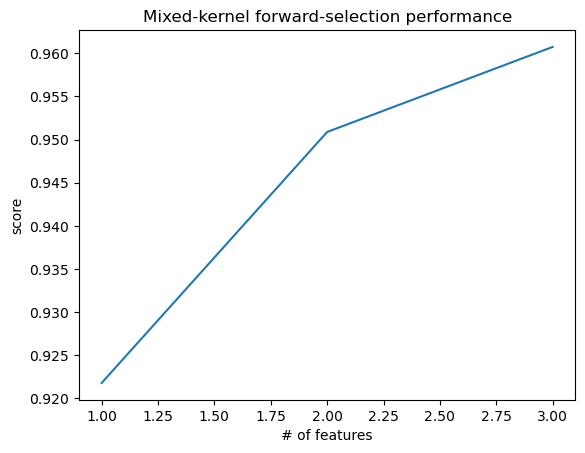

In [ ]:
model.plot_performance(metric="score")
plt.title("Mixed-kernel forward-selection performance")
plt.show()

## Blind evaluation and analytical mixed-kernel gradients

In [ ]:
holdout_decision = model.decision_function(X_test)
print(f"Blind holdout ROC AUC: {roc_auc_score(y_test, holdout_decision):.3f}")
print("Selected features:")
print([X.columns[i] for i in model.unified_features])

Blind holdout ROC AUC: 0.973
Selected features:
['Texture mean', 'Perimeter mean', 'Compactness mean']


In [ ]:
explanation = model.explain_integrated_gradients(
    X_test[:12],
    feature_names=X.columns,
    target=y_test[:12],
    reference_point=np.mean(X_dev, axis=0),
    num_steps=20,
)

mean_absolute_ig = explanation.to_frame().abs().mean().sort_values(ascending=False)
mean_absolute_ig.plot.bar(figsize=(9, 4), ylabel="Mean |integrated gradient|")
plt.title("Mixed-kernel feature contributions")
plt.tight_layout()
plt.show()

NameError: name 'X_dev' is not defined

In [ ]:
model.unified_features

array([ 1,  4, 17, 20, 21, 24, 26, 27, 28, 29])